In [1]:
import sys
import pathlib

# set pythonpath to the main module directory
module_dir = pathlib.Path("..").parent.resolve().parent
if str(module_dir) not in sys.path:
    sys.path.append(str(module_dir))

In [2]:
import torch
from src.utils.env import set_seed

set_seed(42)

torch.set_float32_matmul_precision("high")

In [3]:
import pandas as pd

results_path = "../results.json"

results = pd.read_json(results_path, orient="records")

results.sample(10)

,path,file,benchmark,metric,value
6739,Phi-3-mini-4k-instruct/oasst2/model.layers.11/...,eval-oasst2.json,eval-oasst2,proj_var_rel,0.000138
16053,gemma-2b-it/oasst2/model.norm/gemma-2b-it-oass...,eval-hh-rlhf.json,eval-hh-rlhf,proj_l2_raw,1.128395
12295,Qwen2.5-3B-Instruct/tulu-v2/model.embed_tokens...,eval-oasst2.json,eval-oasst2,score,0.142124
8048,Phi-3-mini-4k-instruct/tulu-v2/model.layers.0/...,eval-lmsys-1m.json,eval-lmsys-1m,proj_var_rel,0.016893
14595,gemma-2b-it/lmsys-1m/model.layers.12/gemma-2b-...,eval-tulu-v2.json,eval-tulu-v2,top10_agr,0.987406
3827,Llama-2-7b-chat-hf/tulu-v2/model.layers.11/Lla...,eval-oasst2.json,eval-oasst2,top1_acc,0.941950
15429,gemma-2b-it/oasst2/model.layers.0/gemma-2b-it-...,eval-tulu-v2.json,eval-tulu-v2,proj_var_rel,0.004191
13435,Qwen2.5-3B-Instruct/tulu-v2/model.layers.24/Qw...,eval-lmsys-1m.json,eval-lmsys-1m,proj_l2_raw,2.870149
88,Llama-2-7b-chat-hf/lmsys-1m/model.embed_tokens...,eval-slim-orca.json,eval-slim-orca,full_l2_raw,0.661949
5181,Phi-3-mini-4k-instruct/lmsys-1m/model.layers.0...,eval-lmsys-1m.json,eval-lmsys-1m,full_l2_raw,20.682533


In [4]:
def parse_path(path: str) -> dict:
    parts = path.split("/")
    model_name = parts[0]
    train_dataset = parts[1]
    layer_name = parts[2]
    exp_name = parts[3]

    return {"model_name": model_name, "train_dataset": train_dataset, "layer_name": layer_name, "exp_name": exp_name}


# now use parse_path to add corresponding columns to the dataframe
parsed = results["path"].apply(parse_path)
results = pd.concat([results, parsed.apply(pd.Series)], axis=1)

# results = results.drop(columns=["path", "file"])

results.sample(20)

,path,file,benchmark,metric,value,model_name,train_dataset,layer_name,exp_name
3449,Llama-2-7b-chat-hf/tulu-v2/model.layers.0/Llam...,eval-slim-orca.json,eval-slim-orca,proj_var_raw,0.304935,Llama-2-7b-chat-hf,tulu-v2,model.layers.0,Llama-2-7b-chat-hf-small-kl-tulu-iter1
9058,Phi-3-mini-4k-instruct/tulu-v2/model.norm/Phi-...,eval-slim-orca.json,eval-slim-orca,proj_l2_rel,0.002056,Phi-3-mini-4k-instruct,tulu-v2,model.norm,Phi-3-mini-4k-instruct-high-kl-tulu-iter1
2114,Llama-2-7b-chat-hf/oasst2/model.layers.11/Llam...,eval-oasst2.json,eval-oasst2,full_var_rel,0.904902,Llama-2-7b-chat-hf,oasst2,model.layers.11,Llama-2-7b-chat-hf-oasst2_kl=2.0-L11-iter1
1089,Llama-2-7b-chat-hf/lmsys-1m/model.layers.21/Ll...,eval-tulu-v2.json,eval-tulu-v2,full_l2_raw,27352.202218,Llama-2-7b-chat-hf,lmsys-1m,model.layers.21,Llama-2-7b-chat-hf-lmsys-1m_kl=20.0-L21-iter1
7418,Phi-3-mini-4k-instruct/oasst2/model.norm/Phi-3...,eval-tulu-v2.json,eval-tulu-v2,proj_l2_raw,7.850944,Phi-3-mini-4k-instruct,oasst2,model.norm,Phi-3-mini-4k-instruct-oasst2_kl=20.0-norm-iter1
9042,Phi-3-mini-4k-instruct/tulu-v2/model.norm/Phi-...,eval-oasst2.json,eval-oasst2,full_l2_raw,5983.051967,Phi-3-mini-4k-instruct,tulu-v2,model.norm,Phi-3-mini-4k-instruct-high-kl-tulu-iter1
3278,Llama-2-7b-chat-hf/tulu-v2/model.layers.0/Llam...,eval-slim-orca.json,eval-slim-orca,full_l2_raw,3.666860,Llama-2-7b-chat-hf,tulu-v2,model.layers.0,Llama-2-7b-chat-hf-large-lr-tulu-iter1
7974,Phi-3-mini-4k-instruct/tulu-v2/model.layers.0/...,eval-tulu-v2.json,eval-tulu-v2,top1_acc,0.910307,Phi-3-mini-4k-instruct,tulu-v2,model.layers.0,Phi-3-mini-4k-instruct-large-lr-tulu-iter1
17516,gemma-2b-it/tulu-v2/model.norm/gemma-2b-it-lar...,eval-lmsys-1m.json,eval-lmsys-1m,proj_l2_raw,6.213491,gemma-2b-it,tulu-v2,model.norm,gemma-2b-it-large-lr-tulu-iter1
13804,Qwen2.5-3B-Instruct/tulu-v2/model.norm/Qwen2.5...,eval-tulu-v2.json,eval-tulu-v2,top1_acc,0.948528,Qwen2.5-3B-Instruct,tulu-v2,model.norm,Qwen2.5-3B-Instruct-large-lr-tulu-iter1


In [5]:
def parse_experiment(exp_name: str) -> dict:
    kl_value = None
    lr_value = None
    early_stop = True
    
    if "no-early-stop" in exp_name:
        early_stop = False
    
    if "baseline" in exp_name or "no-early-stop" in exp_name:
        lr_value = 0.1
        kl_value = 1.0
    
    if "small-lr" in exp_name:
        lr_value = 0.02
        kl_value = 1.0
    
    if "medium-lr" in exp_name:
        lr_value = 0.04
        kl_value = 1.0

    if "large-lr" in exp_name:
        lr_value = 0.25
        kl_value = 1.0

    if "small-kl" in exp_name:
        lr_value = 0.1
        kl_value = 0.5

    if "high-kl" in exp_name:
        lr_value = 0.1
        kl_value = 2.0

    # otherwise, the kl should appear as .._kl=<number>-..

    if "kl=" in exp_name:
        lr_value = 0.1

        kl_part = [part for part in exp_name.split("_") if part.startswith("kl=")]
        if not kl_part:
            raise ValueError(f"Could not find kl value in experiment name: {exp_name}")

        kl_value_str = kl_part[0].split("=")[1].split("-")[0] 
        kl_value = float(kl_value_str)

        kl_value = float(kl_value_str)
        
        
        
    if lr_value is None or kl_value is None:
        raise ValueError(f"Could not parse experiment name: {exp_name}")
        
    return {
        "kl_value": kl_value,
        "lr_value": lr_value,
        "early_stop": early_stop
    }


parsed = results["exp_name"].apply(parse_experiment)
results = pd.concat([results, parsed.apply(pd.Series)], axis=1)

results.sample(10)

,path,file,benchmark,metric,value,model_name,train_dataset,layer_name,exp_name,kl_value,lr_value,early_stop
8416,Phi-3-mini-4k-instruct/tulu-v2/model.layers.11...,eval-hh-rlhf.json,eval-hh-rlhf,full_var_raw,162999.867954,Phi-3-mini-4k-instruct,tulu-v2,model.layers.11,Phi-3-mini-4k-instruct-no-early-stop-tulu-iter1,1.0,0.10,False
10380,Qwen2.5-3B-Instruct/lmsys-1m/model.layers.24/Q...,eval-slim-orca.json,eval-slim-orca,proj_var_rel,0.000257,Qwen2.5-3B-Instruct,lmsys-1m,model.layers.24,Qwen2.5-3B-Instruct-lmsys-1m_kl=2.0-L24-iter1,2.0,0.10,True
6622,Phi-3-mini-4k-instruct/oasst2/model.layers.11/...,eval-oasst2.json,eval-oasst2,full_l2_raw,105860.331826,Phi-3-mini-4k-instruct,oasst2,model.layers.11,Phi-3-mini-4k-instruct-oasst2_kl=0.5-L11-iter1,0.5,0.10,True
3514,Llama-2-7b-chat-hf/tulu-v2/model.layers.0/Llam...,eval-tulu-v2.json,eval-tulu-v2,proj_l2_rel,0.370076,Llama-2-7b-chat-hf,tulu-v2,model.layers.0,Llama-2-7b-chat-hf-small-lr-tulu-iter1,1.0,0.02,True
14731,gemma-2b-it/lmsys-1m/model.layers.6/gemma-2b-i...,eval-hh-rlhf.json,eval-hh-rlhf,full_var_rel,0.718336,gemma-2b-it,lmsys-1m,model.layers.6,gemma-2b-it-lmsys-1m_kl=10.0-L6-iter1,10.0,0.10,True
6163,Phi-3-mini-4k-instruct/oasst2/model.embed_toke...,eval-hh-rlhf.json,eval-hh-rlhf,kl_div,0.003314,Phi-3-mini-4k-instruct,oasst2,model.embed_tokens,Phi-3-mini-4k-instruct-oasst2_kl=10.0-embed_to...,10.0,0.10,True
15746,gemma-2b-it/oasst2/model.layers.6/gemma-2b-it-...,eval-hh-rlhf.json,eval-hh-rlhf,proj_l2_rel,0.244387,gemma-2b-it,oasst2,model.layers.6,gemma-2b-it-oasst2_kl=0.5-L6-iter1,0.5,0.10,True
17490,gemma-2b-it/tulu-v2/model.norm/gemma-2b-it-hig...,eval-tulu-v2.json,eval-tulu-v2,full_l2_raw,5287.400711,gemma-2b-it,tulu-v2,model.norm,gemma-2b-it-high-kl-tulu-iter1,2.0,0.10,True
9397,Qwen2.5-3B-Instruct/lmsys-1m/model.embed_token...,eval-tulu-v2.json,eval-tulu-v2,kl_div,0.026558,Qwen2.5-3B-Instruct,lmsys-1m,model.embed_tokens,Qwen2.5-3B-Instruct-lmsys-1m_kl=0.5-embed_toke...,0.5,0.10,True
4005,Llama-2-7b-chat-hf/tulu-v2/model.layers.21/Lla...,eval-tulu-v2.json,eval-tulu-v2,full_var_raw,27605.111371,Llama-2-7b-chat-hf,tulu-v2,model.layers.21,Llama-2-7b-chat-hf-high-kl-tulu-iter1,2.0,0.10,True


In [6]:
# now please do the following: 
# group the data by (train_dataset, model_name, layer_name)

# i want to compare results across the following axes:
# how does the KL value affect the metrics (make sure that you only compare experiments with the same lr_value and early_stop value when comparing kl_value, and vice versa)
# how does lr_value affect the metrics (make sure that you only compare experiments with the same kl_value and early_stop value when comparing lr_value, and vice versa)
# how does early stopping affect the metrics (make sure that you only compare experiments with the same kl_value and lr_value when comparing early stopping, and vice versa)

In [7]:
results.columns

Index(['path', 'file', 'benchmark', 'metric', 'value', 'model_name',
       'train_dataset', 'layer_name', 'exp_name', 'kl_value', 'lr_value',
       'early_stop'],
      dtype='str')

In [8]:
results["train_dataset"].unique()

<ArrowStringArray>
['lmsys-1m', 'oasst2', 'tulu-v2']
Length: 3, dtype: str

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

x_axis = "kl_value"
metric_names = ["top1_acc", "top10_agr", "proj_l2_rel", "kl_div"]  # change this to the desired metric names

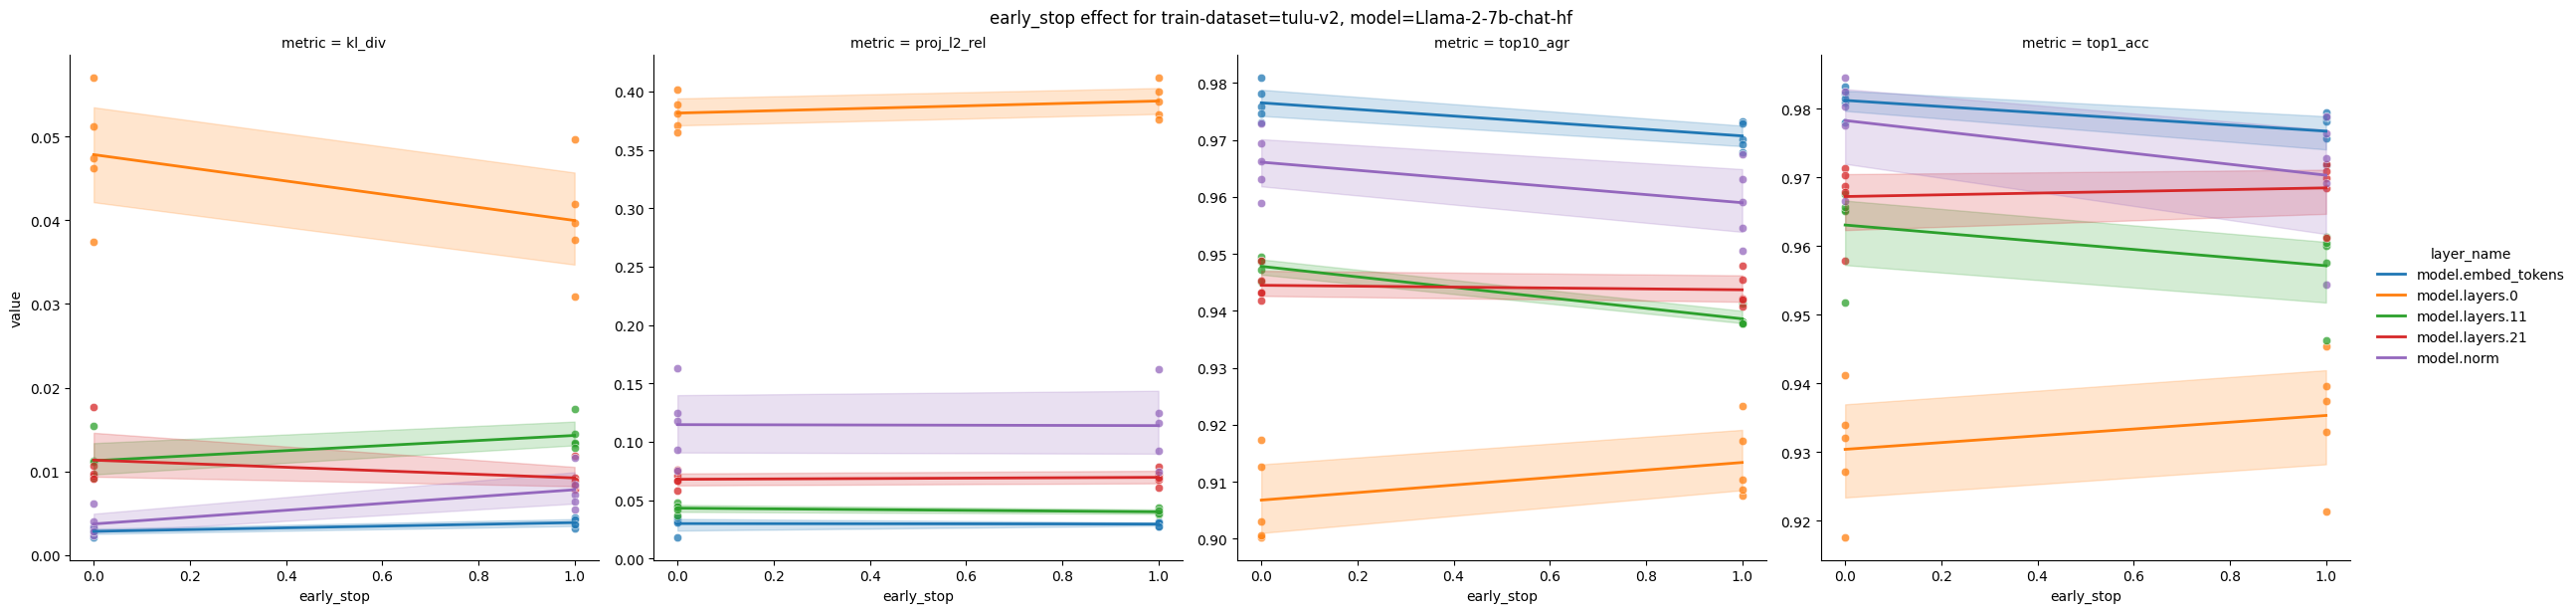

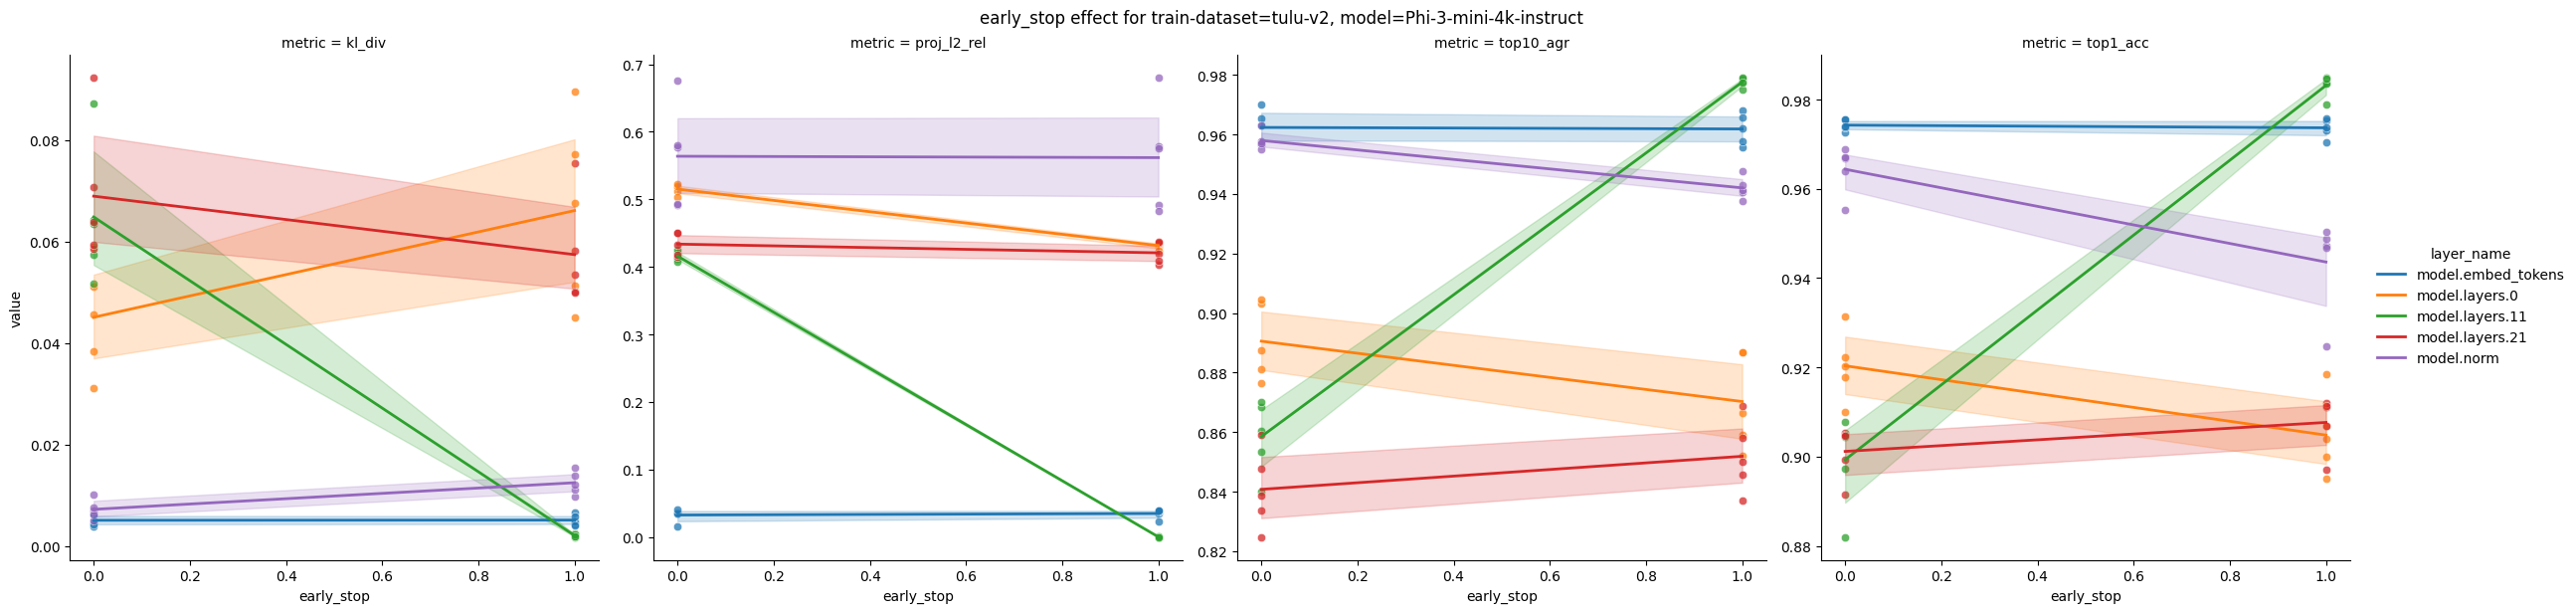

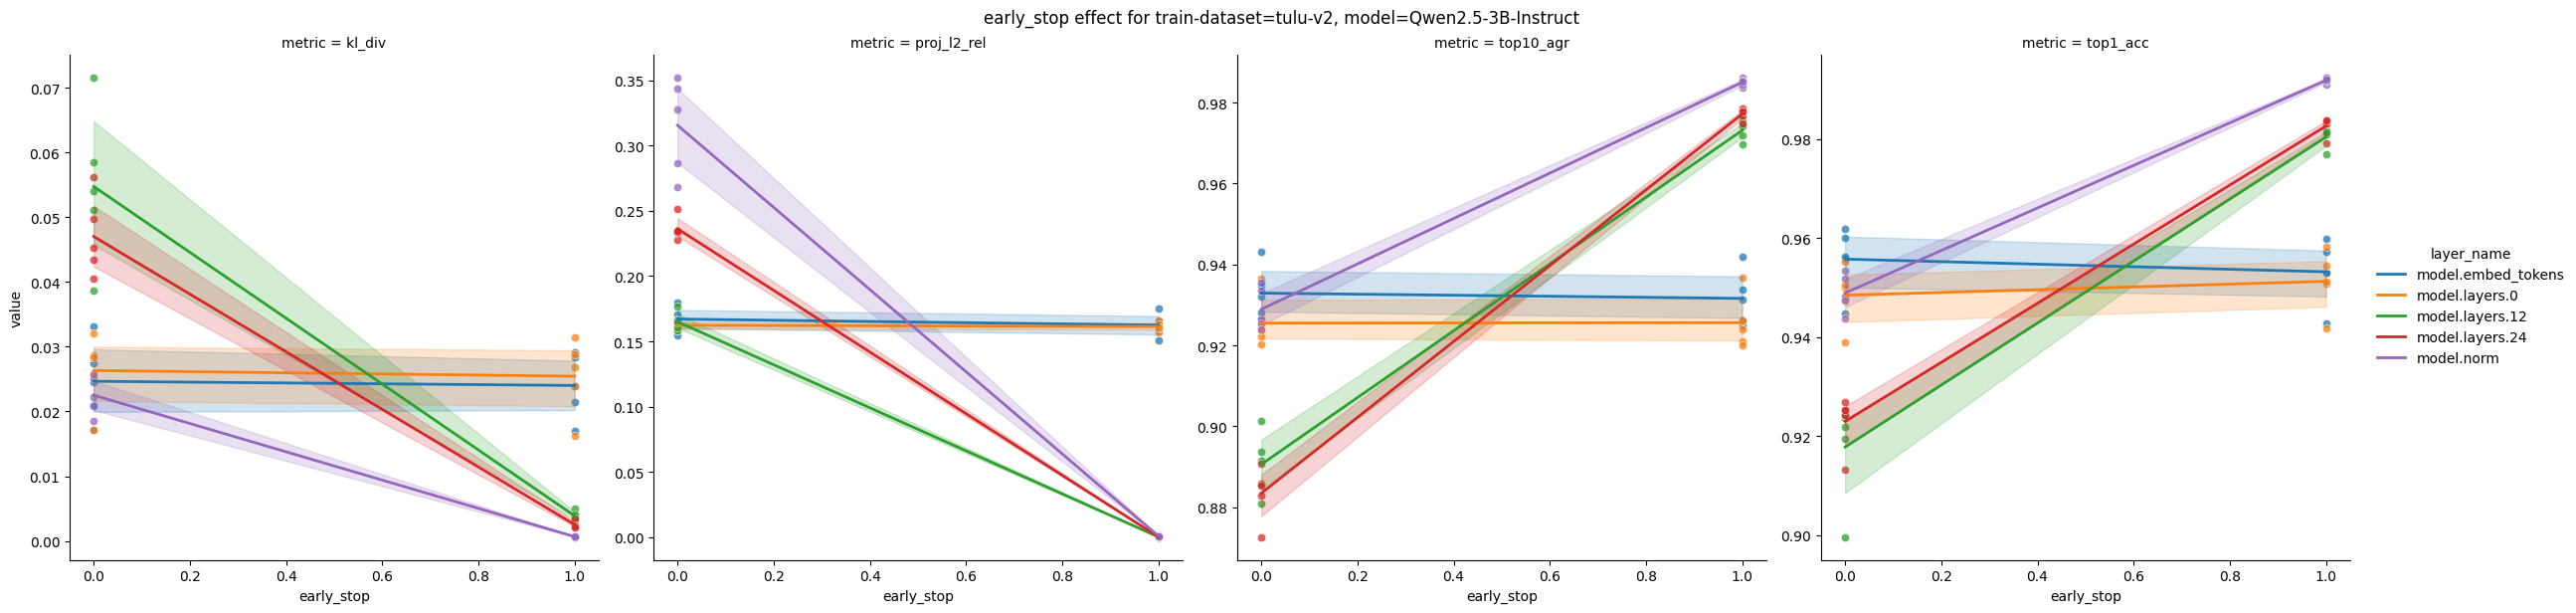

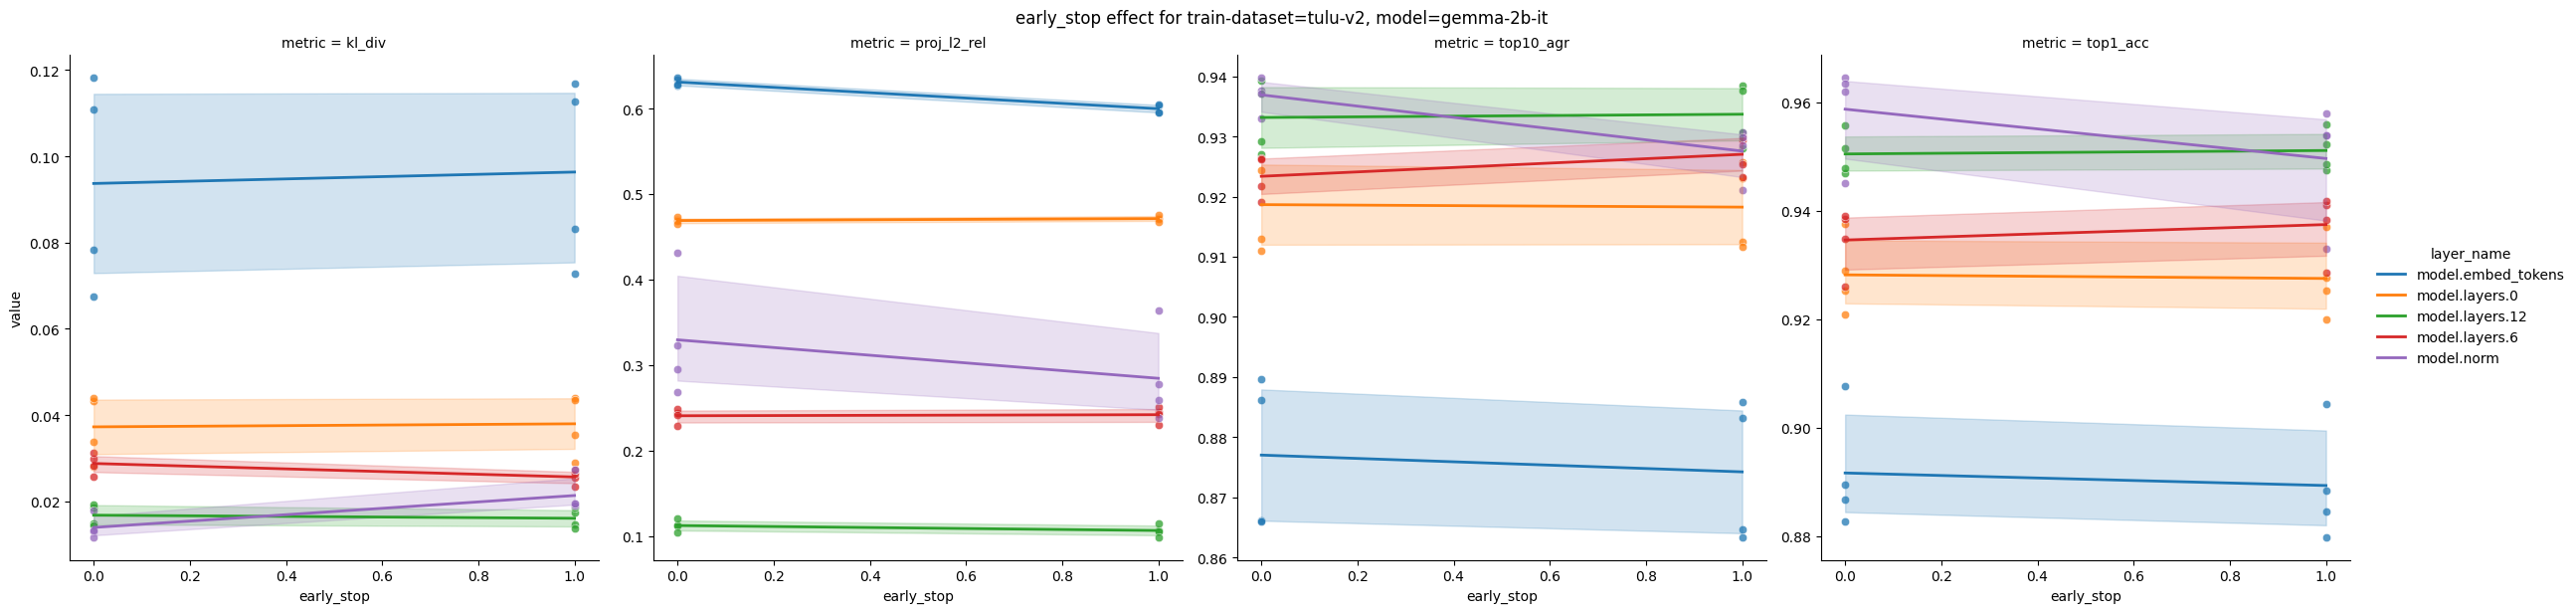

In [10]:
# check effect of early stopping
filtered = results[(results["lr_value"] == 0.1) & (results["kl_value"] == 1.0)]
x_axis = "early_stop"

# Group by train_dataset, model_name
grouped = filtered.groupby(['train_dataset', 'model_name'])

# Plot effect of x_axis parameter per layer for all metrics
for name, group in grouped:
    sub_group = group[(group['metric'].isin(metric_names))]
    if not sub_group.empty and len(sub_group[x_axis].unique()) > 1:
        col_wrap = min(4, len(metric_names))
        g = sns.FacetGrid(sub_group, col='metric', hue='layer_name', col_wrap=col_wrap, sharey=False, height=6)
        g.map_dataframe(sns.scatterplot, x=x_axis, y='value', alpha=0.75, marker='o')
        g.map_dataframe(sns.lineplot, x=x_axis, y='value', estimator='mean', alpha=1, linewidth=2, err_kws={'alpha': 0.2})
        g.add_legend()
        g.fig.suptitle(f'{x_axis} effect for train-dataset={name[0]}, model={name[1]}', y=1.02)
        plt.show()

In [11]:
filtered = results[(results["lr_value"] == 0.1) & (results["early_stop"] == True)]

filtered = filtered[filtered["kl_value"] < 10.0]

# Group by train_dataset, model_name
grouped = filtered.groupby(['train_dataset', 'model_name'])

# Plot effect of x_axis parameter per layer for all metrics
for name, group in grouped:
    sub_group = group[(group['metric'].isin(metric_names))]
    if not sub_group.empty and len(sub_group[x_axis].unique()) > 1:
        col_wrap = min(4, len(metric_names))
        g = sns.FacetGrid(sub_group, col='metric', hue='layer_name', col_wrap=col_wrap, sharey=False, height=6)
        g.map_dataframe(sns.scatterplot, x=x_axis, y='value', alpha=0.75, marker='o')
        g.map_dataframe(sns.lineplot, x=x_axis, y='value', estimator='mean', alpha=1, errorbar=None, linewidth=2)
        g.add_legend()
        g.fig.suptitle(f'{x_axis} effect for train-dataset={name[0]}, model={name[1]}', y=1.02)
        plt.show()

In [12]:
print(filtered["benchmark"].unique())

<ArrowStringArray>
[  'eval-hh-rlhf',  'eval-lmsys-1m',    'eval-oasst2', 'eval-slim-orca',
   'eval-tulu-v2']
Length: 5, dtype: str


In [13]:
metric_names = ["proj_l2_rel", "kl_div"]

filtered = filtered[filtered["benchmark"] == "eval-lmsys-1m"]

# Group by train_dataset, model_name
grouped = filtered.groupby(['model_name'])


# Plot effect of x_axis parameter per layer for all metrics
for name, group in grouped:
    sub_group = group[(group['metric'].isin(metric_names))]
    if not sub_group.empty and len(sub_group[x_axis].unique()) > 1:
        col_wrap = min(4, len(metric_names))
        g = sns.FacetGrid(sub_group, col='metric', hue='layer_name', col_wrap=col_wrap, sharey=False, height=6)
        g.map_dataframe(sns.scatterplot, x=x_axis, y='value', alpha=0.85, marker='o')
        g.map_dataframe(sns.lineplot, x=x_axis, y='value', estimator='mean', alpha=1, linewidth=2, err_kws={'alpha': 0.2})
        g.add_legend()
        g.fig.suptitle(f'{x_axis} effect for model={name[0]}', y=1.02)
        plt.show()

In [ ]:
# CONCLUSIONS:
# KL >= 10 is not good at all
# training dataset is important
# early stopping is also important, especially for Qwen model...

# TODO:
# - run training on slim-orca and hh-rlhf with kl=0.5
# - benchmark all training datasets with kl=0.5